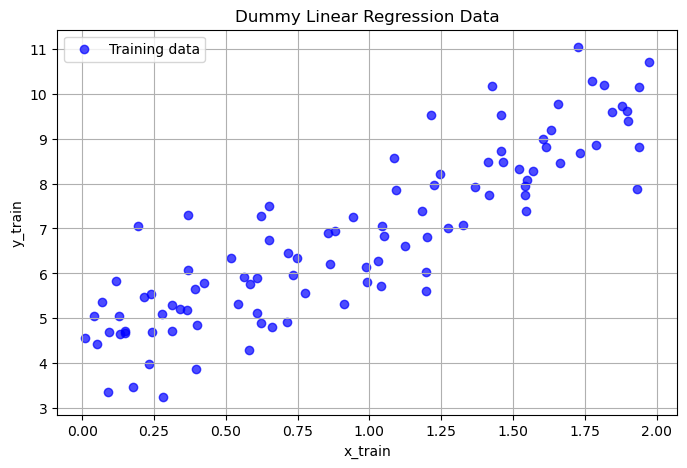

Features shape is: (100, 1)
Target shape is: (100, 1)


In [3]:
import numpy as np
import matplotlib.pyplot as plt


# Set the seed for reproducibility
np.random.seed(42)

# Number of samples
num_samples = 100

# Generate random x values (features)
x_train = 2 * np.random.rand(num_samples, 1)

# Generate corresponding y values with a linear relationship (y = 4 + 3x + noise)
true_slope = 3
true_intercept = 4
noise = np.random.randn(num_samples, 1)

y_train = true_intercept + true_slope * x_train + noise

# Plotting the data
plt.figure(figsize = (8, 5))
plt.scatter(x_train, y_train, color = "blue", label = "Training data", alpha = 0.7)
plt.title("Dummy Linear Regression Data")
plt.xlabel("x_train")
plt.ylabel("y_train")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape is:", x_train.shape)
print("Target shape is:", y_train.shape)

In [18]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [19]:
x_train = pd.DataFrame(x_train)
y_train = pd.DataFrame(y_train)

In [1]:
def information_gain(X_train, Y_train, f_name):
    values = np.sort(np.unique(X_train.iloc[:,f_name]))
    thresholds = np.unique(X_train.iloc[:,f_name])
    # threshold = np.unique(x)
    total = len(Y_train)
    temp_best_x_left=None
    temp_best_y_left=None
    temp_best_x_right=None
    temp_best_y_right=None
    

    root_var = np.var(Y_train.values.reshape(-1))
    # H_dn = 0 # initial entropy
    best_IG = -1
    
    
    for th in thresholds:

        left_b_x = X_train[X_train[f_name] <= th]
        left_b_y = Y_train[X_train[f_name]<=th]

        right_b_x = X_train[X_train[f_name]>th]
        right_b_y = Y_train[X_train[f_name]>th]
        
        left_m = len(left_b_x)
        right_m = len(right_b_x)
        
        left_var = (left_m/total) * np.var(left_b_y.values.reshape(-1))

        right_var = (right_m/total) * np.var(right_b_y.values.reshape(-1))
        
        weighted_var = left_var + right_var
        IG = root_var - weighted_var
        if IG > best_IG:
            best_IG = IG
            best_threshold = th 
            temp_best_x_right = right_b_x
            temp_best_y_right = right_b_y
            temp_best_x_left = left_b_x
            temp_best_y_left = left_b_y
    
    return best_IG, [temp_best_x_left, temp_best_x_right], [temp_best_y_left,temp_best_y_right], best_threshold 

In [32]:
number_classes = len(np.unique(y_train[0]))
depth = 3

best_x_csvs_branchs = [x_train]
best_y_csvs_branchs = [y_train]


tree = {}##################3
root_node = []
for d in range(depth):
    next_x_branches = []
    next_y_branches = []
    
    for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_csvs_branchs, best_y_csvs_branchs):
        IG_value = -np.inf
        best_feature = None
        temp_best_x_csvs_branch = None
        temp_best_y_csvs_branch = None
        
        y_pred = None
        best_th = None
        
        for f_name in range(0,x_train.shape[1]):
            IG, x_csvs_branch, y_csvs_branch, threshold = information_gain(best_x_csvs_branch, best_y_csvs_branch, f_name)
            
            if IG > IG_value:
                
                IG_value = IG
                if IG_value>0:
                    temp_best_x_csvs_branch = x_csvs_branch
                    temp_best_y_csvs_branch = y_csvs_branch
                    
                    best_feature = f_name
                    best_th = threshold
                         
                else:
                    # y_pred = None
                    y_pred= best_y_csvs_branch[0].value_counts().idxmax()
                    # best_feature = le.inverse_transfor (np.unique(y))[0]
        
        print(best_feature, IG_value)

        node_id = id(best_x_csvs_branch)##################
        root_node.append(node_id)
        tree[node_id] = {             ###################3
            "feature": best_feature,
            "ig": IG_value,
            "children":[],
            "th":best_th
        } #####################################
        
        if temp_best_x_csvs_branch is not None:
            next_x_branches.extend(temp_best_x_csvs_branch)
            next_y_branches.extend(temp_best_y_csvs_branch)

            for child_x in temp_best_x_csvs_branch: ###########
               
                tree[node_id]["children"].append(id(child_x))
                
    best_x_csvs_branchs = next_x_branches
    best_y_csvs_branchs = next_y_branches
    
    if d == depth-1:
        for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_csvs_branchs, best_y_csvs_branchs):
            y_pred = best_y_csvs_branch[0].value_counts().idxmax()
             # y_pred= best_y_csvs_branch[0].value_counts().idxmax()
            node_id = id(best_x_csvs_branch)
            tree[node_id]={
                 
                "feature": None,
                "ig": None,
                "children": [],
                "pred":y_pred
            }#####################
        
    

C:\Users\ADMIN\anaconda3_new\Lib\site-packages\numpy\_core\fromnumeric.py:4318: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ADMIN\anaconda3_new\Lib\site-packages\numpy\_core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\ADMIN\anaconda3_new\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


0 2.3361005207533037
0 0.46883163026747576
0 0.3611335666392158
0 0.1073290913070275
0 0.12389284386348842
0 0.09554808921810365
0 0.11684302733443785


In [33]:
tree

{3003574766624: {'feature': 0,
  'ig': np.float64(2.3361005207533037),
  'children': [3003612380784, 3003611078160],
  'th': np.float64(1.2022300234864176)},
 3003612380784: {'feature': 0,
  'ig': np.float64(0.46883163026747576),
  'children': [3003612601088, 3003612602432],
  'th': np.float64(0.6219646434313244)},
 3003611078160: {'feature': 0,
  'ig': np.float64(0.3611335666392158),
  'children': [3003612599856, 3003612602320],
  'th': np.float64(1.5703519227860272)},
 3003612601088: {'feature': 0,
  'ig': np.float64(0.1073290913070275),
  'children': [3003612600752, 3003611077712],
  'th': np.float64(0.31203728088487304)},
 3003612602432: {'feature': 0,
  'ig': np.float64(0.12389284386348842),
  'children': [3003612599632, 3003612601200],
  'th': np.float64(1.0401360423556216)},
 3003612599856: {'feature': 0,
  'ig': np.float64(0.09554808921810365),
  'children': [3003612600080, 3003612600304],
  'th': np.float64(1.2150897038028767)},
 3003612602320: {'feature': 0,
  'ig': np.float6

In [38]:
y_pred = []
for i in range(len(x_train)):
    nid = root_node[0]
    while 1:
        search = tree[nid]["feature"]
        if search is not None :
            feature_name = tree[nid]["feature"]
            value=x_train[feature_name][i]

            if value<=tree[nid]["th"]:
                children_id=0
            else:
                children_id = 1
            nid = tree[nid]["children"][children_id]     
        else:
            y_pred.append(tree[nid]["pred"])
            break
y_true_labels = y_train

y_pred_flat = np.array([
    x.item() if isinstance(x, np.ndarray) else x
    for x in y_pred
])
y_true = y_true_labels.values.ravel()
y_pred = np.array(y_pred).ravel()

mse = np.mean((y_true - y_pred) ** 2)
print("MSE:", mse)

MSE: 0.8249940899023942
